<a href="https://colab.research.google.com/github/Juan-Vega18/-ANALISIS-EXPLOR-DE-DATOS---63510/blob/main/EXAMEN_PARCIAL_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
pip install gapminder

In [31]:
pip install kagglehub[pandas-datasets]

In [181]:
from gapminder import gapminder
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.ticker import ScalarFormatter


In [9]:
df_og = gapminder
#MI AÑO ES 1977.

In [6]:
#GDP vs Life expentancy (years), mi año es 1977
#gapminder world poster 2015

Bueno, lo primero para poder hacer el grafico es entender como está conformado. Tenemos 4 variables, income que es el eje x inferior ademas de dos sub categorias, poor a la izquierda y rich a la derecha, tenemos health que es el eje Y medido en life expectancy con un sub plot de texto a los lados que dice: sick y healty. En el eje x superior tenemos los income levels distribuidos hasta 4. Esos niveles podrian ser de hecho, cuartiles.

Tenemos tambien los paises en circulos diferentes tamaños, esto corresponde al tamaño de poblacion, con 3 tamaños explicados, de 1 millon hasta 1000 millones de habitantes.
Finalmente tenemos un recuadro explicativo que explica que es todo el grafico, el color de cada pais segun su región y el tamaño del pais.

Para poder hacer algo así o similar, vamos a necesitar primero saber que columnas de datos y que estructura tenemos

In [10]:
df_og.head()

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


Ya que vemos, tenemos el pais, su continente, tambien el año (solo nos va a interesar el año 1977), la expectativa de vida, la poblacion y el gdpPercap. Basicamente tenemos todo.


In [12]:
#1 Filtramos el dataset completo y nos quedamos solo con 1977

df = df_og[df_og['year'] == 1977]

Ahora vemos algo bien interesante y es que la escala del eje x NO está en escala normal sino en escala logarítmica, dado que tenemos valores MUY diferentes entre paises y una escala normal no parece ser lo mas conveniente.

Vamos primero a calcular los cuartiles y clasificaremos a cada pais segun su cuartil en income levels.

Definimos categorías:
LEVEL 1 -> Cuartil 1 -> 0 - 0.25
LEVEL 2 -> Cuartil 2 -> 0.25 - 0.50
LEVEL 3 -> Cuartil 3 -> 0.50 - 0.75
LEVEL 4 -> Cuartil 4 -> 0.75 - 1

In [20]:
#Al parecer pandas tiene una funcion especifica para eso que es pd.qcut()
#qcut() -> corte por cuartiles

#Creamos una nueva columna donde vamos a meter la categoría de cuartiles
df['income_levels'] = pd.qcut(df['gdpPercap'],
                              q=4,
                              labels=['Level 1', 'Level 2', 'Level 3', 'Level 4'])
#Basicamente cortamos por cuartiles y a cada uno le ponemos nombre

df['income_levels'].value_counts() #Verificamos que si esté mas o menos balanceado



/tmp/ipykernel_6789/2859377144.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['income_levels'] = pd.qcut(df['gdpPercap'],


,count
income_levels,
Level 1,36
Level 4,36
Level 2,35
Level 3,35


In [88]:
#Vamos a convertir cada continente en un color

def rgb255_to_01(r,g,b):
    return (r/255, g/255, b/255) #Creo una funcion que me convierta los rgb255 al valor en escala 0-1 que acepta matplotlib

def edge_color(color, amount=0.5):
    r,g,b = color
    return (
        r + (1 - r) * amount,
        g + (1 - g) * amount,
        b + (1 - b) * amount
    ) #Toma el color original y le resta suma su diferencia con el valor extremo multiplicado por la cantidad, basicamente, lo hace mas claro (al mismo color)


color_map = {
    'Africa': rgb255_to_01(245, 66, 108),
    'Americas': rgb255_to_01(223, 227, 113),
    'Asia': rgb255_to_01(74, 166, 237),
    'Europe': rgb255_to_01(87, 217, 119),
    'Oceania': rgb255_to_01(227, 148, 84)
}

df['color'] = df['continent'].map(color_map)
df['edge_color'] = df['color'].apply(lambda c: edge_color(c, 0.5))

df.head()

/tmp/ipykernel_6789/3163138206.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['color'] = df['continent'].map(color_map)
/tmp/ipykernel_6789/3163138206.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['edge_color'] = df['color'].apply(lambda c: edge_color(c, 0.5))


,country,continent,year,lifeExp,pop,gdpPercap,income_levels,color,edge_color
5,Afghanistan,Asia,1977,38.438,14880372,786.113360,Level 1,"(0.2901960784313726, 0.6509803921568628, 0.929...","(0.6450980392156862, 0.8254901960784313, 0.964..."
17,Albania,Europe,1977,68.930,2509048,3533.003910,Level 2,"(0.3411764705882353, 0.8509803921568627, 0.466...","(0.6705882352941177, 0.9254901960784314, 0.733..."
29,Algeria,Africa,1977,58.014,17152804,4910.416756,Level 3,"(0.9607843137254902, 0.25882352941176473, 0.42...","(0.9803921568627452, 0.6294117647058823, 0.711..."
41,Angola,Africa,1977,39.483,6162675,3008.647355,Level 2,"(0.9607843137254902, 0.25882352941176473, 0.42...","(0.9803921568627452, 0.6294117647058823, 0.711..."
53,Argentina,Americas,1977,68.481,26983828,10079.026740,Level 3,"(0.8745098039215686, 0.8901960784313725, 0.443...","(0.9372549019607843, 0.9450980392156862, 0.721..."


Ahora si vamos a hacer el grafico.
gpdPercap eje X
lifeExp eje Y
pop tamaño
continent - col = color
country = etiquetas

/tmp/ipykernel_6789/2881782718.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['gdp_log'] = np.log10(df['pop'])


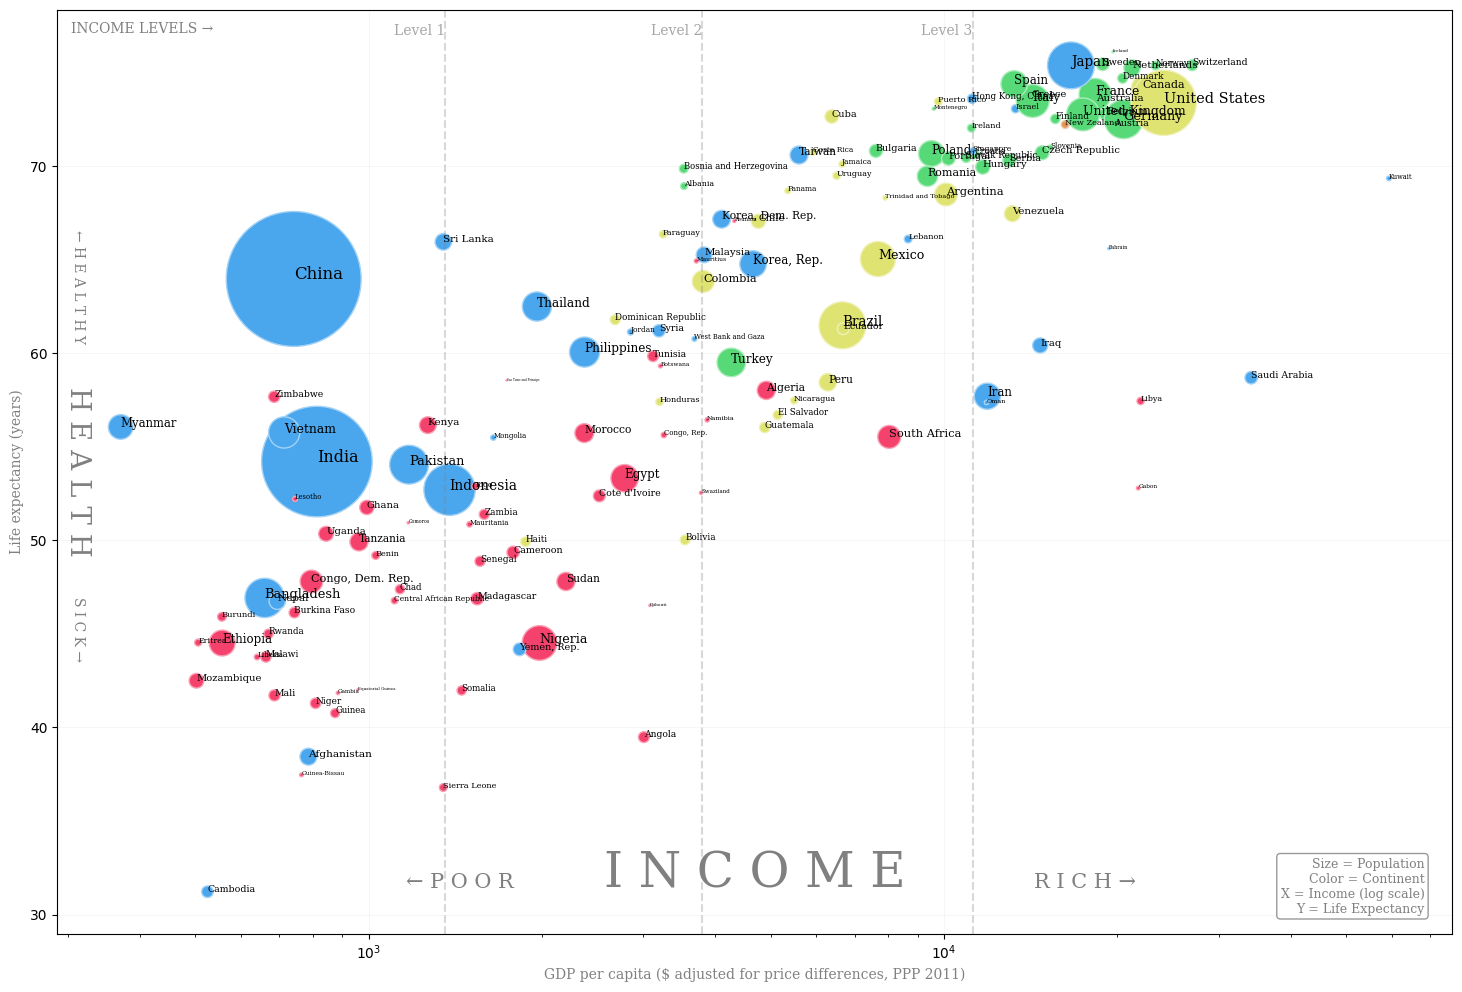

In [249]:

#GRAFICO
plt.figure(figsize=(18,12))
plt.scatter(df['gdpPercap'],
            df['lifeExp'],#SCATTER -> nube de puntos
            s=df['pop']/100000,#Ajustamos la nube de puntos según el tamaño... Hay que ir probando
            c=df['color'],
            alpha=1,#El alpha es la transparencia, pero en el grafico original las burbujas NO tenian transparencia, asi que lo dejaré en
            edgecolors = df['edge_color'])

#plt.text(x,y,texto) entonces, lo que hacemos con este for es recorrer todos el dataset, le ponemos el nombre a cada uno dibujando la coordenada
#en el grafico con los parametros, iloc[i] encuentra la coordenada...
#la verdad no se ve muy bien pero no encontré como arreglarlo o mejorarlo... queda como tarea.

#Intento de solución para el texto:
df['gdp_log'] = np.log10(df['pop'])
#Rangos de la escala
min_log = df['gdp_log'].min()
max_log = df['gdp_log'].max()
min_font = 2
max_font = 12

def scale_font(log_val):
    normalized = (log_val - min_log) / (max_log - min_log)
    return min_font + normalized * (max_font - min_font)
    #Reescalamos la fuente. Eso funciona así
    #Tomamos el valor minimo de la fuente, sumamos el log_val normalizado (restamos con el valor minimo y dividimos por el rango), finalmente, multiplicamos por la escala (valor maximo
    #de la fuente menos el valor minimo)


for i in range(len(df)):
    fs = float(scale_font(df['gdp_log'].iloc[i]))
    plt.text(
        df['gdpPercap'].iloc[i],
        df['lifeExp'].iloc[i],
        df['country'].iloc[i],
        fontfamily = 'serif',
        fontweight='light',
        fontsize=fs
    )

plt.grid(
    True,
    linestyle='-',  #tipo de línea
    linewidth=0.5,
    color='gray',
    alpha=0.1
)

#TEXTO DE INCOME
plt.text(
    0.5, 0.05,                     #posición relativa
    'I N C O M E',
    transform=plt.gca().transAxes, #usamos coordenadas relativas dado que tenemos escala log en x
    fontsize=35,
    color='gray',
    alpha=1,
    ha='center', #centra el texto
    fontfamily = 'serif',
    fontweight='light'
)
#TEXTO DE RICH
plt.text(
    0.7, 0.05,                     #posición relativa
    'R I C H →',
    transform=plt.gca().transAxes, #usamos coordenadas relativas dado que tenemos escala log en x
    fontsize=15,
    color='gray',
    alpha=1,
    fontfamily = 'serif',
    fontweight='light'
)

#TEXTO DE POOR
plt.text(
    0.25, 0.05,                     #posición relativa
    '← P O O R ',
    transform=plt.gca().transAxes, #usamos coordenadas relativas dado que tenemos escala log en x
    fontsize=15,
    color='gray',
    alpha=1,
    fontfamily = 'serif',
    fontweight='light'
)

#TEXTO DE HEALTH

plt.text(
    0.005, 0.5,
    'H E A L T H',
    transform=plt.gca().transAxes,
    fontsize=20,
    color='gray',
    alpha=1,
    rotation=270,
    va='center',
    fontfamily = 'serif',
    fontweight='light'
)


#TEXTO DE HEALTHY

plt.text(
    0.01, 0.7,
    '← H E A L T H Y',
    transform=plt.gca().transAxes,
    fontsize=10,
    color='gray',
    alpha=1,
    rotation=270,
    va='center',
    fontfamily = 'serif',
    fontweight='light'
)

#TEXTO DE HEALTHY

plt.text(
    0.01, 0.33,
    'S I C K →',
    transform=plt.gca().transAxes,
    fontsize=10,
    color='gray',
    alpha=1,
    rotation=270,
    va='center',
    fontfamily = 'serif',
    fontweight='light'
)



#Lineas de los cuartiles

q1 = df['gdpPercap'].quantile(0.25)
q2 = df['gdpPercap'].quantile(0.50)
q3 = df['gdpPercap'].quantile(0.75)

plt.axvline(q1, color='gray', linestyle='--', alpha=0.3)
plt.axvline(q2, color='gray', linestyle='--', alpha=0.3)
plt.axvline(q3, color='gray', linestyle='--', alpha=0.3)

#Texto de los cuartiles
plt.text(q1, 77, 'Level 1', ha='right', fontfamily = 'serif', fontweight='light', alpha=0.7, color='gray')
plt.text(q2, 77, 'Level 2', ha='right', fontfamily = 'serif', fontweight='light', alpha=0.7, color='gray')
plt.text(q3, 77, 'Level 3', ha='right', fontfamily = 'serif', fontweight='light', alpha=0.7, color='gray')


#TEXTO DE INCOME LEVELS

plt.text(
    0.01, 0.979,
    'INCOME LEVELS →',
    transform=plt.gca().transAxes,
    fontsize=10,
    color='gray',
    alpha=1,
    rotation=0,
    va='center',
    fontfamily = 'serif',
    fontweight='light'
)

# GRID DEL FONDO

plt.gca().set_axisbelow(True) #Para que el grid quede detras de los puntos
plt.xscale('log')#Aqui ajustamos la escala del eje x en log


# RECUADRO EXPLICATIVO DE LA DERECHA INFERIOR

plt.text(
    0.98, 0.02,
    'Size = Population\nColor = Continent\nX = Income (log scale)\nY = Life Expectancy',
    transform=plt.gca().transAxes,
    ha='right',
    va='bottom',
    fontsize=9,
    fontfamily = 'serif', fontweight='light', alpha=1, color='gray',
    bbox=dict(
        facecolor='white',
        edgecolor='gray',
        alpha=0.8,
        boxstyle='round'
    )
)

plt.xlabel('GDP per capita ($ adjusted for price differences, PPP 2011)', fontfamily = 'serif', fontweight='light', alpha=1, color='gray')
plt.ylabel('Life expectancy (years)', fontfamily = 'serif', fontweight='light', alpha=1, color='gray')
plt.show()
